<a target="_blank" href="https://colab.research.google.com/github/jgromero/dasoc-ap/blob/main/conspiraciones/clasificacion-conspiraciones.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
</a>

# Clasificación de texto

El conjunto de datos utilizado en este ejemplo proviene de la tarea de "Oppositional thinking analysis: Conspiracy theories vs critical thinking narratives" de [PAN 2024](https://pan.webis.de/clef24/pan24-web/oppositional-thinking-analysis.html).

Consiste en una colección de textos extraidos de Telegram anotados manualmente como mensajes "críticos" (`CRITICAL`) frente a "conspirativos" (`CONSPIRACY`).

En este cuaderno se exploran varias aproximaciones a la clasificación de textos usando redes neuronales.


## Carga de datos

Leer datos.

In [1]:
import gdown

# Descargar el archivo dataset.csv desde Google Drive
url = 'https://drive.google.com/uc?id=178ixCNZzdrueSH8FgufOXFPfkmAGMUxH'
output = 'dataset.csv'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=178ixCNZzdrueSH8FgufOXFPfkmAGMUxH
To: /content/dataset.csv
100%|██████████| 2.34M/2.34M [00:00<00:00, 53.4MB/s]


'dataset.csv'

In [2]:
import pandas as pd

data = pd.read_csv('dataset.csv')
data

,text,category
0,THIS IS MASSIVE Australian Senator Malcolm Rob...,CONSPIRACY
1,“ I ’m deeply concerned that the push to vacci...,CRITICAL
2,2021 : They wanted to know your vaccination st...,CRITICAL
3,Anthony Fauci once again defended brutal Chine...,CRITICAL
4,Proof has emerged showing that death from Wuha...,CRITICAL
...,...,...
3995,Police in Australia are warning that unvaccina...,CRITICAL
3996,I personally do n’t believe Putin would set of...,CONSPIRACY
3997,Pfizer lied . We know that . There 's no doubt...,CRITICAL
3998,""" It is utterly bizarre and inexplicable - Dr....",CRITICAL


In [3]:
print(f"An example of CONSPIRACY: {data['text'][0]}")
print(f"An example of CRITICAL: {data['text'][1]}")

An example of CONSPIRACY: THIS IS MASSIVE Australian Senator Malcolm Roberts exposes nanotech found in the Covid ‘ vaccines ’ and says they are genocide . He is the first politician to expose this !   SHARE https :// t . me / LauraAbolichannel 
An example of CRITICAL: “ I ’m deeply concerned that the push to vaccinate these children is nothing more than a dystopian experiment with unknown consequences . ” — Rep. Louie Gohmert ( R - Texas ) # TheDefender https :// childrenshealthdefense . org / defender / fda - eua - covid - shots - infants - young - kids / 


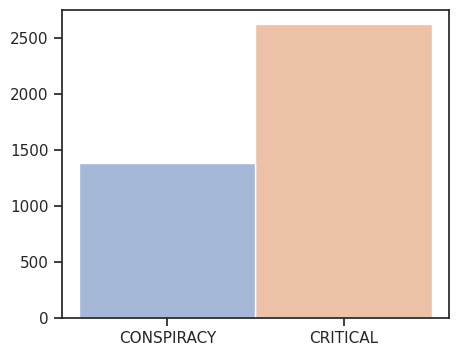

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(5, 4))
sns.set_theme(style="ticks")
sns.histplot(data=data, x='category', hue='category', legend=False)
plt.xlabel('')
plt.ylabel('')
plt.show()

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(data['text'], data['category'], test_size=0.2, random_state=42)

Codificar la variable de predicción `category` usando [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html), que por defecto cambia las categorías por números enteros.

(Con dos etiquetas de clasificación conocidas no sería necesario [`LabelEncoder`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html), se usa a modo ilustrativo.)

In [6]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_numerical = label_encoder.fit_transform(y_train)
y_test_numerical = label_encoder.transform(y_test)

## Clasificación usando índices

### Valores enteros como índices

En primer lugar, creamos una capa de codificación de texto con [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/).

Esta capa tiene opciones básicas para gestionar texto en un modelo de Keras. Por defecto, transforma un conjunto de cadenas en una lista de vectores (`output_mode = "int"`), en la que cada uno de estos vectores es una lista de números enteros correspondientes a los índices de tokens.

- Crear [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/), especificando diversos parámetros.
- Aplicar [`adapt()`](https://www.tensorflow.org/api_docs/python/tf/keras/layers/TextVectorization#adapt) para construir el diccionario a partir de datos.

In [7]:
from keras.layers import TextVectorization

vectorizer = TextVectorization(
    max_tokens=20000,
    standardize="lower_and_strip_punctuation",
    output_mode="int",
    output_sequence_length=10)

vectorizer.adapt(X_train)

Podemos recuperar el vocabulario completo construido.

In [8]:
vectorizer.get_vocabulary()[:10]

['',
 '[UNK]',
 np.str_('the'),
 np.str_('to'),
 np.str_('of'),
 np.str_('and'),
 np.str_('a'),
 np.str_('in'),
 np.str_('is'),
 np.str_('for')]

De esta forma, esta capa puede codificar secuencias de texto. Podemos usarla de forma aislada o dentro de un modelo.

In [9]:
input_data = [
    ["Covid adviser Fauci gets revoked security protection"],
    ["A COVID-19 vaccine was developed by Pfizer"]
]
vectorizer(input_data)

<tf.Tensor: shape=(2, 10), dtype=int64, numpy=
array([[  13, 4629,  235, 1133, 8583, 1340, 1157,    0,    0,    0],
       [   6,  871,   12,   40, 1292,   26,   86,    0,    0,    0]])>

Usando la capa de [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/), podemos crear y entrenar un modelo de clasificación.

In [10]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense

vectorizer = TextVectorization(
    max_tokens=20000,
    output_sequence_length=100)
vectorizer.adapt(X_train)

model_indices = Sequential([
    vectorizer,
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

In [11]:
model_indices.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_indices.fit(
    tf.convert_to_tensor(X_train),
    y_train_numerical,
    epochs=50,
    validation_split=0.2)

Epoch 1/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - accuracy: 0.5310 - loss: 648.5067 - val_accuracy: 0.5609 - val_loss: 367.7029
Epoch 2/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.5837 - loss: 291.1164 - val_accuracy: 0.5594 - val_loss: 293.6807
Epoch 3/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6256 - loss: 185.2163 - val_accuracy: 0.5828 - val_loss: 263.6270
Epoch 4/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6671 - loss: 136.0945 - val_accuracy: 0.5641 - val_loss: 237.1751
Epoch 5/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6882 - loss: 106.1165 - val_accuracy: 0.5875 - val_loss: 222.0217
Epoch 6/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7123 - loss: 81.4992 - val_accuracy: 0.5938 - val_loss: 207.0733
Epoch 7/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7388 - loss: 65.6997 - val_accuracy: 0.5813 - val_loss: 200.9326
Epoch 8/50
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7608 - loss: 51.7349 - 

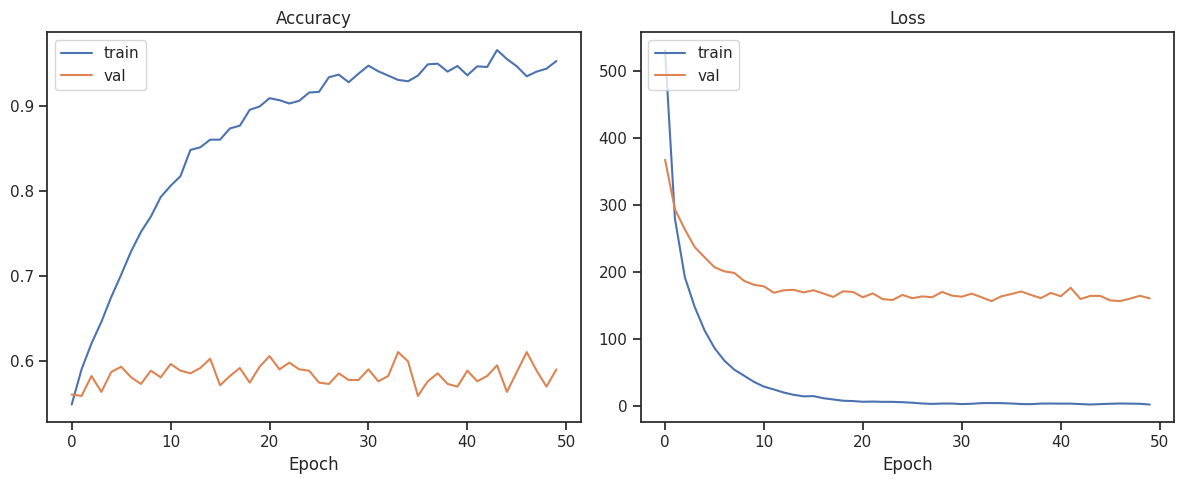

In [12]:
# Creamos una función para crear las gráficas que reutilizaremos en adelante
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy
    ax1.plot(history.history['accuracy'], label='train')
    ax1.plot(history.history['val_accuracy'], label='val')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.legend(loc='upper left')

    # Loss
    ax2.plot(history.history['loss'], label='train')
    ax2.plot(history.history['val_loss'], label='val')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.legend(loc='upper left')

    plt.tight_layout()
    plt.show()

plot_training_history(history)

### Codificaciones one-hot y tf-idf

Podemos utilizar otro tipo de codificaciones con la misma capa [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/); por ejemplo, one-hot o tf-idf.

In [13]:
# Ejemplo de codificación tipo one-hot
vectorizer = TextVectorization(
    max_tokens=20000,
    output_mode="multi_hot")
vectorizer.adapt(X_train) # Construye el vocabulario a partir de los datos de entrenamiento

input_data = [
    ["Covid adviser Fauci gets revoked security protection"],
    ["A COVID-19 vaccine was developed by Pfizer"]
]
vectorizer(input_data) # Convierte los textos en una representación binaria
pd.DataFrame(vectorizer(input_data).numpy(), columns=vectorizer.get_vocabulary())

,[UNK],the,to,of,and,a,in,is,for,that,...,2816,2814,2800000,280,27s,2796427,2794886,2791253,2780342438778873,27793
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Y entrenar un modelo de clasificación de la forma habitual.

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7582 - loss: 0.5507 - val_accuracy: 0.8641 - val_loss: 0.3571
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9581 - loss: 0.1569 - val_accuracy: 0.8719 - val_loss: 0.3572
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9902 - loss: 0.0666 - val_accuracy: 0.8797 - val_loss: 0.3777
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9978 - loss: 0.0298 - val_accuracy: 0.8578 - val_loss: 0.4009
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9973 - loss: 0.0244 - val_accuracy: 0.8641 - val_loss: 0.4264
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9996 - loss: 0.0103 - val_accuracy: 0.8687 - val_loss: 0.4675
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9991 - loss: 0.0095 - val_accuracy: 0.8641 - val_loss: 0.4703
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9994 - loss: 0.0063 - val_accuracy: 0.8703 - val_loss

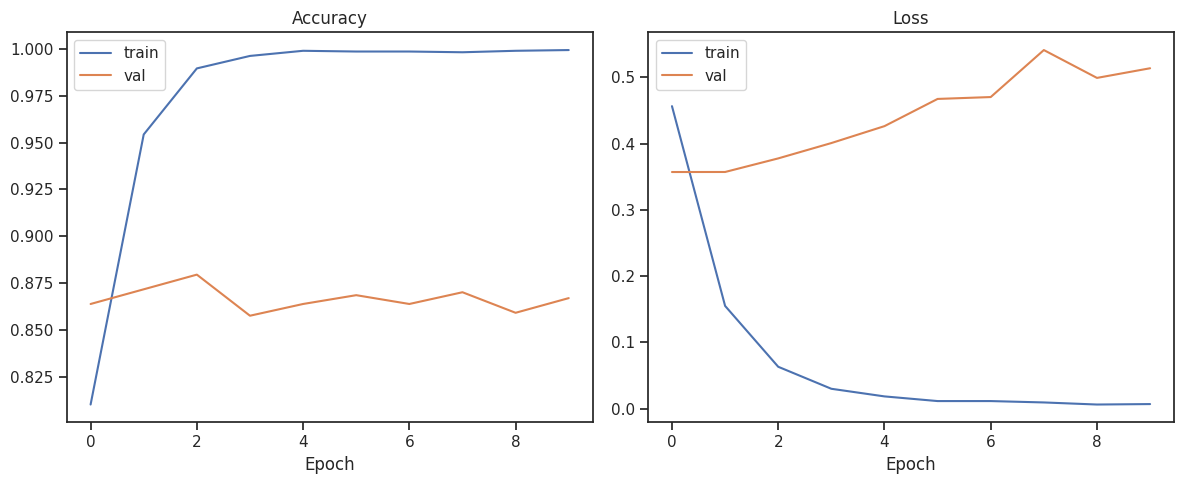

In [14]:
# Modelo one-hot
model_onehot = Sequential([
    vectorizer,
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_onehot.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_onehot.fit(
    tf.convert_to_tensor(X_train),
    y_train_numerical,
    epochs=10,
    validation_split=0.2)

plot_training_history(history)

In [15]:
# Ejemplo de codificación tipo tf-idf
vectorizer = TextVectorization(
    max_tokens=20000,
    output_mode="tf-idf")
vectorizer.adapt(X_train)

input_data = [
    ["Covid adviser Fauci gets revoked security protection"],
    ["A COVID-19 vaccine was developed by Pfizer"]
]
vectorizer(input_data)
pd.DataFrame(vectorizer(input_data).numpy(), columns=vectorizer.get_vocabulary())

,[UNK],the,to,of,and,a,in,is,for,that,...,2816,2814,2800000,280,27s,2796427,2794886,2791253,2780342438778873,27793
0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,1.019169,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7445 - loss: 0.5283 - val_accuracy: 0.8375 - val_loss: 0.4261
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9858 - loss: 0.0816 - val_accuracy: 0.8500 - val_loss: 0.4644
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9986 - loss: 0.0232 - val_accuracy: 0.8562 - val_loss: 0.5259
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9995 - loss: 0.0118 - val_accuracy: 0.8469 - val_loss: 0.5424
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9997 - loss: 0.0052 - val_accuracy: 0.8516 - val_loss: 0.6524
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 0.0061 - val_accuracy: 0.8359 - val_loss: 0.5958
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9972 - loss: 0.0054 - val_accuracy: 0.8406 - val_loss: 0.6476
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.9998 - loss: 0.0023 - val_accuracy: 0.8484 - val_lo

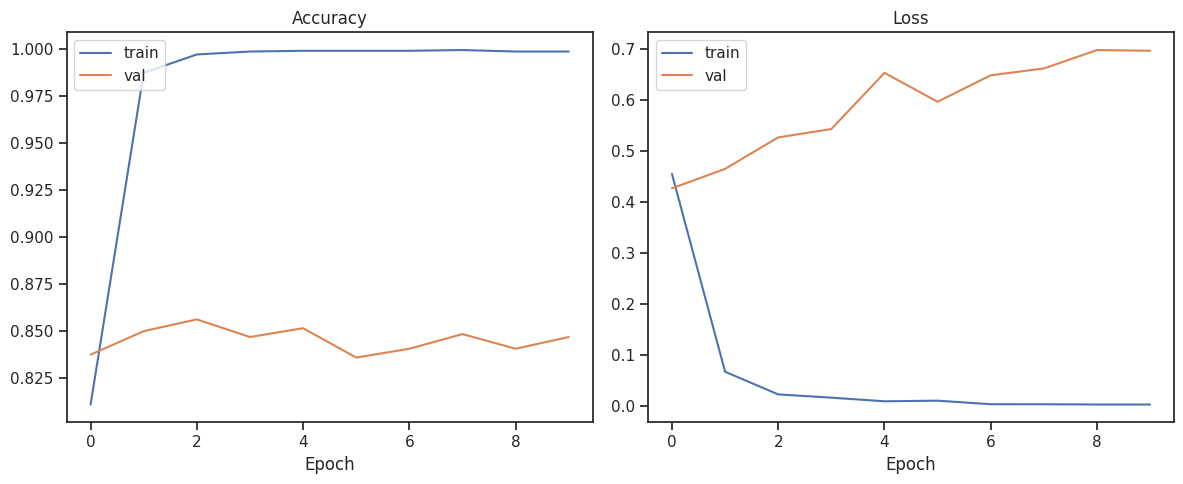

In [16]:
# Modelo tf-idf
model_tfidf = Sequential([
    vectorizer,
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_tfidf.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_tfidf.fit(
    tf.convert_to_tensor(X_train),
    y_train_numerical,
    epochs=10,
    validation_split=0.2)

plot_training_history(history)

## Clasificación usando _embeddings_

### Entrenando una capa de _embeddings_

Podemos utilizar una capa de [`Embedding`](https://keras.io/api/layers/core_layers/embedding/) para que la red aprenda una representación de los tokens optimizada para este problema.

(*NOTA*: Esta capa no tiene una arquitectura especializada, como por ejemplo CBOW, simplemente tiene pesos entrenables para obtener la codificación en _embeddings_ para el problema.)

En este ejemplo se hace una conversión explícita de los textos de entrada a representación binaria usando [`TextVectorization`](https://keras.io/api/layers/preprocessing_layers/text/text_vectorization/) y `vectorizer()`. No obstante, también podría integrarse como una capa más de la red, tal y como se hace en el ejemplo anterior.

Epoch 1/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.6847 - loss: 0.6072 - val_accuracy: 0.7922 - val_loss: 0.4567
Epoch 2/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9589 - loss: 0.1307 - val_accuracy: 0.8438 - val_loss: 0.3874
Epoch 3/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9977 - loss: 0.0080 - val_accuracy: 0.8344 - val_loss: 0.4116
Epoch 4/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9990 - loss: 0.0023 - val_accuracy: 0.8359 - val_loss: 0.4139
Epoch 5/5
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9991 - loss: 0.0018 - val_accuracy: 0.8422 - val_loss: 0.4183


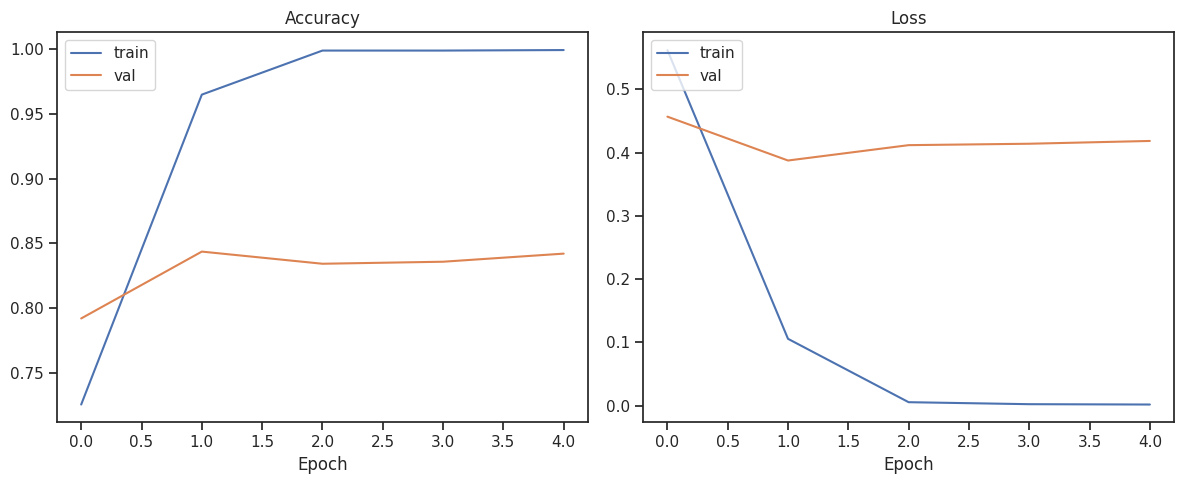

In [17]:
from keras.layers import Embedding, Flatten, Input
from keras.models import Model

max_length = 100
max_tokens = 20000

vectorizer = TextVectorization(
  max_tokens=max_tokens,
  output_mode="int",
  output_sequence_length=max_length,
)
vectorizer.adapt(X_train) # Construye el vocabulario a partir de los datos de entrenamiento

model_embedding = Sequential([
    Embedding(input_dim=max_tokens, output_dim=256),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_embedding.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

X_train_numerical = vectorizer(tf.convert_to_tensor(X_train)) # Convierte los textos en una representación binaria
history = model_embedding.fit(
    X_train_numerical,
    y_train_numerical,
    epochs=5,
    validation_split=0.2
)

plot_training_history(history)

### Usando _embeddings_ precalculados _clásicos_ (Glove, fasttext, etc.)

En lugar de entrenar nuestra propia capa [`Embedding`](https://keras.io/api/layers/core_layers/embedding/), podemos usar _embeddings_ preentrenados, como por ejemplo [Glove](https://nlp.stanford.edu/projects/glove/). Para ello, necesitamos:

* Preparar el `vectorizer`
* Descargar Glove
* Preparar los valores descargados para insertarlos como pesos en la capa [`Embedding`](https://keras.io/api/layers/core_layers/embedding/)
  * Crear diccionario token -> embedding
  * Crear matriz de embeddings
* Crear el modelo especificando estos pesos
* Entrenar el modelo

In [18]:
# Preparar el vectorizer
vectorizer = TextVectorization(
  max_tokens=max_tokens,
  output_mode="int",
  output_sequence_length=max_length,
)

vectorizer.adapt(X_train)

In [19]:
# Descargar GloVe
import os
import urllib.request
import zipfile

glove_url  = "http://nlp.stanford.edu/data/glove.6B.zip"
glove_path = "glove.6B.zip"
glove_dir  = "glove"

if not os.path.exists(glove_path):
    print("Downloading GloVe embeddings...")
    urllib.request.urlretrieve(glove_url, glove_path)

# Extraer fichero
if not os.path.exists(glove_dir):
    print("Extracting GloVe embeddings...")
    with zipfile.ZipFile(glove_path, "r") as zip_ref:
        zip_ref.extractall(glove_dir)

print("GloVe embeddings are ready!")

Extracting GloVe embeddings...
GloVe embeddings are ready!


In [20]:
import numpy as np
from tqdm import tqdm

# Crear diccionario de embeddings, mostrando las 5 primeras líneas del fichero
embedding_index = {}
with open('glove/glove.6B.100d.txt', encoding='utf-8') as f:

    # Contar número de líneas y mostrar las 5 primeras
    num_lines = 0
    for i, line in enumerate(f):
        if i < 5:
            print(line.strip())
        num_lines += 1
    f.seek(0)

    # Crear diccionario token -> embedding
    for i, line in enumerate(tqdm(f, desc="Reading GloVe file", total=num_lines)):
        values = line.split()
        word = values[0]
        coefs = np.asarray(values[1:], dtype='float32')
        embedding_index[word] = coefs

# Crear la matriz de embeddings
embedding_dim = 100
vocab_size = len(vectorizer.get_vocabulary())
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for i, word in enumerate(tqdm(vectorizer.get_vocabulary(), desc="Processing vocabulary")):
    embedding_vector = embedding_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

the -0.038194 -0.24487 0.72812 -0.39961 0.083172 0.043953 -0.39141 0.3344 -0.57545 0.087459 0.28787 -0.06731 0.30906 -0.26384 -0.13231 -0.20757 0.33395 -0.33848 -0.31743 -0.48336 0.1464 -0.37304 0.34577 0.052041 0.44946 -0.46971 0.02628 -0.54155 -0.15518 -0.14107 -0.039722 0.28277 0.14393 0.23464 -0.31021 0.086173 0.20397 0.52624 0.17164 -0.082378 -0.71787 -0.41531 0.20335 -0.12763 0.41367 0.55187 0.57908 -0.33477 -0.36559 -0.54857 -0.062892 0.26584 0.30205 0.99775 -0.80481 -3.0243 0.01254 -0.36942 2.2167 0.72201 -0.24978 0.92136 0.034514 0.46745 1.1079 -0.19358 -0.074575 0.23353 -0.052062 -0.22044 0.057162 -0.15806 -0.30798 -0.41625 0.37972 0.15006 -0.53212 -0.2055 -1.2526 0.071624 0.70565 0.49744 -0.42063 0.26148 -1.538 -0.30223 -0.073438 -0.28312 0.37104 -0.25217 0.016215 -0.017099 -0.38984 0.87424 -0.72569 -0.51058 -0.52028 -0.1459 0.8278 0.27062
, -0.10767 0.11053 0.59812 -0.54361 0.67396 0.10663 0.038867 0.35481 0.06351 -0.094189 0.15786 -0.81665 0.14172 0.21939 0.58505 -0.52158 

Processing vocabulary: 100%|██████████| 20000/20000 [00:00<00:00, 538878.13it/s]


In [21]:
# Construir el modelo usando la matriz de embeddings
model_glove = Sequential([
    Embedding(input_dim=vocab_size, output_dim=embedding_dim, weights=[embedding_matrix], trainable=False),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_glove.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

Epoch 1/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - accuracy: 0.6572 - loss: 0.6264 - val_accuracy: 0.7547 - val_loss: 0.5036
Epoch 2/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8673 - loss: 0.3313 - val_accuracy: 0.7156 - val_loss: 0.5655
Epoch 3/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9575 - loss: 0.1735 - val_accuracy: 0.6734 - val_loss: 0.6831
Epoch 4/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9839 - loss: 0.0868 - val_accuracy: 0.7594 - val_loss: 0.6197
Epoch 5/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9992 - loss: 0.0306 - val_accuracy: 0.7531 - val_loss: 0.6881
Epoch 6/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9981 - loss: 0.0292 - val_accuracy: 0.7453 - val_loss: 0.7300
Epoch 7/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9997 - loss: 0.0115 - val_accuracy: 0.7437 - val_loss: 0.7882
Epoch 8/10
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9998 - loss: 0.0081 - val_accuracy: 0.7312 - val_loss

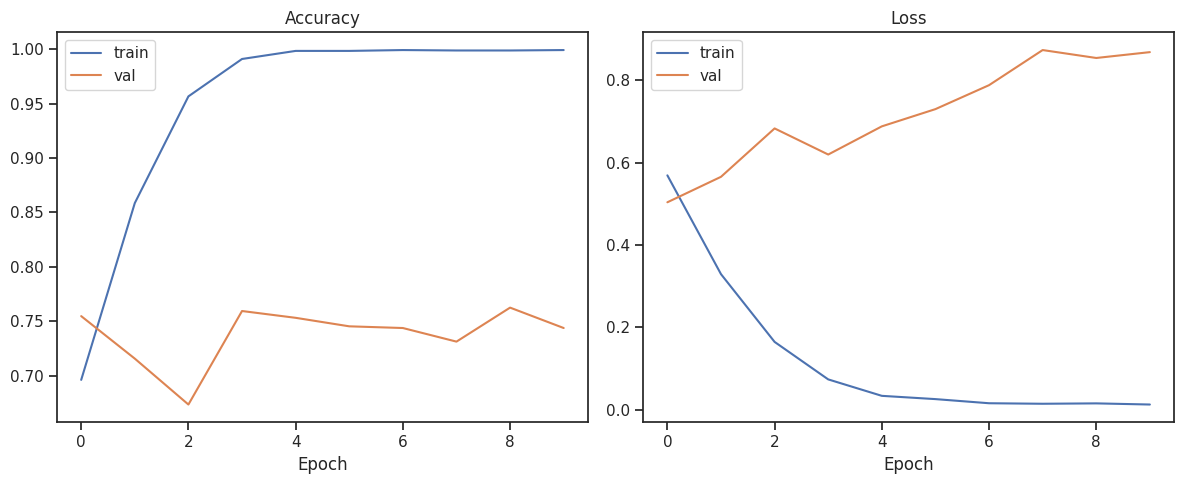

In [22]:
# Entrenar el modelo
X_train_numerical = vectorizer(tf.convert_to_tensor(X_train))
history = model_glove.fit(
    X_train_numerical,
    y_train_numerical,
    epochs=10,
    validation_split=0.2
)

plot_training_history(history)

### Usando _embeddings_ procedentes de un modelo de lenguaje (con [`SentenceTransformer`](https://sbert.net/))
Los modelos de lenguaje actuales suelen incluir una sección de generación de _embeddings_. Muchos de estos modelos ofrecen la posibilidad de consultar el _embedding_ para una un token o para una frase completa.

En este ejemplo, usamos [`SentenceTransformer`](https://sbert.net/), de la biblioteca [`sentence_transformers`](https://sbert.net/), para generar los _embeddings_. Esta aproximación es más sencilla que la anterior para GloVe, ya que disponemos de utilidades para interactuar con los modelos.

In [23]:
from sentence_transformers import SentenceTransformer

# Cargar el modelo preentrenado
transformer = SentenceTransformer('all-MiniLM-L6-v2')

# Generar embeddings para los datos de entrenamiento
X_train_embeddings_st = transformer.encode(X_train.tolist())

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

En este caso es especialmente interesante visualizar los _embeddings_. Para ello, reducimos la dimensionalidad a 2 usando [UMAP](https://umap-learn.readthedocs.io/en/latest/) y dibujamos en dos dimensiones.

In [24]:
import umap

reducer = umap.UMAP(n_components=2, random_state=42)
X_train_2d = reducer.fit_transform(X_train_embeddings_st)

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


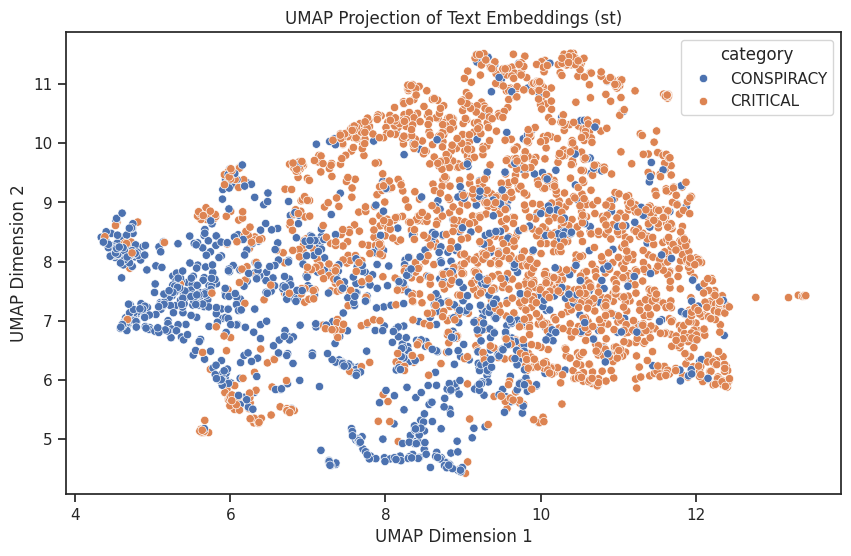

In [25]:
import seaborn as sns

df_embeddings_st = pd.DataFrame(X_train_2d, columns=['UMAP Dimension 1', 'UMAP Dimension 2'])
df_embeddings_st['category'] = y_train.tolist()

plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")
sns.scatterplot(x='UMAP Dimension 1', y='UMAP Dimension 2', hue='category', data=df_embeddings_st)
plt.title('UMAP Projection of Text Embeddings (st)')
plt.show()

Finalmente, con los _embeddings_ obtenidos podemos entrenar un nuevo modelo.

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.6807 - loss: 0.6167 - val_accuracy: 0.8062 - val_loss: 0.4564
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8161 - loss: 0.4314 - val_accuracy: 0.8281 - val_loss: 0.3821
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8365 - loss: 0.3700 - val_accuracy: 0.8469 - val_loss: 0.3611
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8393 - loss: 0.3611 - val_accuracy: 0.8562 - val_loss: 0.3465
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8660 - loss: 0.3179 - val_accuracy: 0.8531 - val_loss: 0.3522
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8644 - loss: 0.3116 - val_accuracy: 0.8672 - val_loss: 0.3363
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8766 - loss: 0.2977 - val_accuracy: 0.8609 - val_loss: 0.3354
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8732 - loss: 0.3038 - val_accuracy: 0.8594 - val_loss:

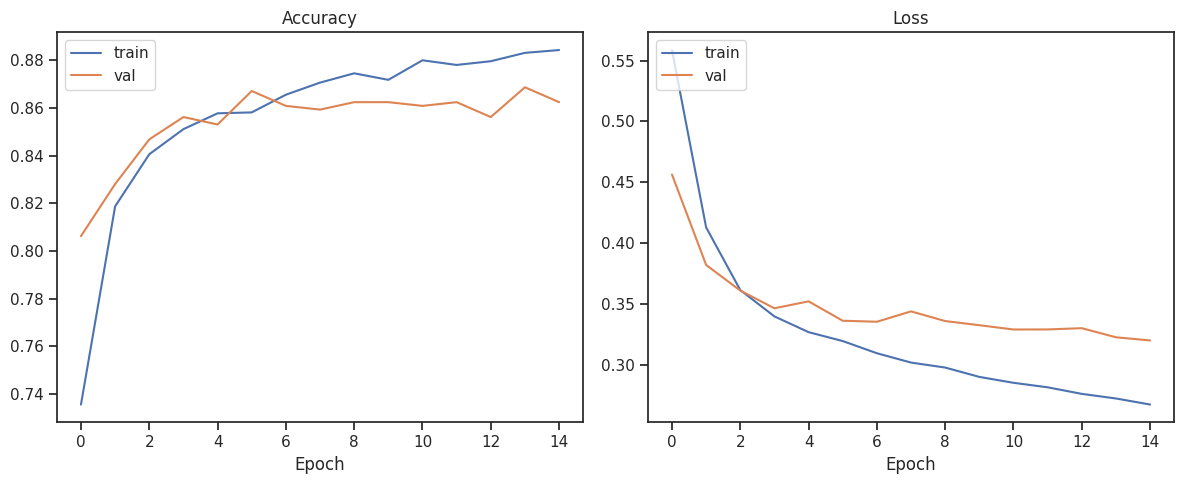

In [26]:
model_transformer = Sequential([
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_transformer.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_transformer.fit(
    X_train_embeddings_st,
    y_train_numerical,
    epochs=15,
    validation_split=0.2)

plot_training_history(history)

### Usando _embeddings_ procedentes de un modelo de lenguaje (con GPT)


A continuación se muestra cómo obtener y utilizar embeddings generados por un modelo de lenguaje comercial (GPT), siguiendo métodos similares a los utilizados previamente con otros embeddings.

En primer lugar, nos conectamos a la API de OpenAI usando una clave (ojo, es de pago).

In [27]:
import getpass
from openai import OpenAI

# my_api_key = '' # Cambiar por tu clave de API de OpenAI
# -- o alternativamente, solicitar la clave de API de OpenAI al usuario --
my_api_key = getpass.getpass("Por favor, introduce tu clave de API de OpenAI: ")

client = OpenAI(api_key=my_api_key)

Por favor, introduce tu clave de API de OpenAI: ··········


In [28]:
# Comprobar conexión con OpenAI
completion = client.chat.completions.create(
  model="gpt-4.1",
  messages=[
    {"role": "system", "content": "You are a poetic assistant, skilled in explaining complex programming concepts with creative flair."},
    {"role": "user", "content": "Compose a poem that explains the concept of loops in programming."}
  ]
)

print(completion.choices[0].message)

ChatCompletionMessage(content='Imagine a task that repeats like the tide—  \nA list to be counted, or stars to be eyed.  \nYou need to repeat things, not write lines anew;  \nThis magical pattern is called a **loop**.\n\nA loop is a dance in the language of code,  \nA circle that cycles, a path well-trod road.  \nIt whispers: "_Do this, then check if you’re done;_  \n_If not, do it over—continue the run!_"\n\nThere’s the **while loop**, that waits for a test to be true:  \n“_While not at the end, there’s more work to do!_”  \nLike a river that flows while rain clouds persist,  \nIt halts only once no conditions are missed.\n\nThe **for loop** is different, precise in its style—  \nIt counts from the start, stops after a while.  \n"**For** each apple on branches so leafy and green,  \nTake one, then the next, through all to be seen."\n\n**Infinite loops** are the trickster’s delight—  \nThey go on and on, through day and through night.  \nUnless you command them to break and be free,  \

Calcular embeddings siguiendo [las instrucciones de OpenAI](https://cookbook.openai.com/examples/get_embeddings_from_dataset).

In [29]:
import tiktoken
from typing import List

encoding = tiktoken.get_encoding("cl100k_base")

def get_embedding(text: str, model="text-embedding-3-small", **kwargs) -> List[float]:
    # replace newlines, which can negatively affect performance.
    text = text.replace("\n", " ")
    response = client.embeddings.create(input=[text], model=model, **kwargs)
    return response.data[0].embedding

In [30]:
# Limitamos a los primeros textos y añadimos una barra de progreso
limit_texts = 3200 # Cambiar límite (max. 3200) o eliminar .head() en este bloque y el siguientes

tqdm.pandas()
X_train_embeddings_gpt = X_train.head(limit_texts).progress_apply(lambda x: get_embedding(x))
X_train_embeddings_gpt = np.array(X_train_embeddings_gpt.to_list())

100%|██████████| 3200/3200 [09:07<00:00,  5.84it/s]


Podemos visualizar estos embeddings igual que antes.

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


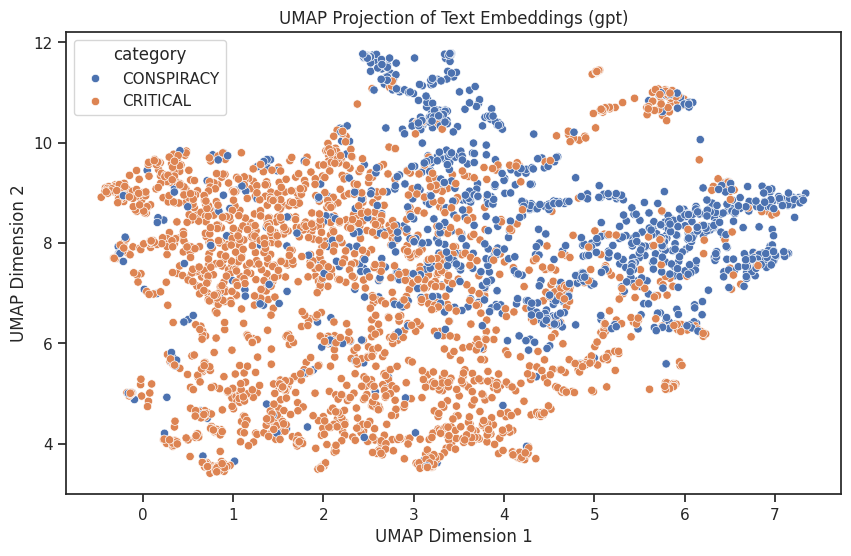

In [31]:
reducer = umap.UMAP(n_components=2, random_state=42)
X_train_2d = reducer.fit_transform(X_train_embeddings_gpt)

df_embeddings_gpt = pd.DataFrame(X_train_2d, columns=['UMAP Dimension 1', 'UMAP Dimension 2'])
df_embeddings_gpt['category'] = y_train.head(limit_texts).tolist()

plt.figure(figsize=(10, 6))
sns.set_theme(style="ticks")
sns.scatterplot(x='UMAP Dimension 1', y='UMAP Dimension 2', hue='category', data=df_embeddings_gpt)
plt.title('UMAP Projection of Text Embeddings (gpt)')
plt.show()

Y, finalmente, entrenar nuestro modelo:

Epoch 1/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 0.7142 - loss: 0.5524 - val_accuracy: 0.8672 - val_loss: 0.3311
Epoch 2/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8993 - loss: 0.2800 - val_accuracy: 0.8828 - val_loss: 0.2938
Epoch 3/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9031 - loss: 0.2508 - val_accuracy: 0.8828 - val_loss: 0.2745
Epoch 4/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9200 - loss: 0.2077 - val_accuracy: 0.8906 - val_loss: 0.2712
Epoch 5/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9153 - loss: 0.2017 - val_accuracy: 0.8859 - val_loss: 0.2752
Epoch 6/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9146 - loss: 0.1979 - val_accuracy: 0.8891 - val_loss: 0.2711
Epoch 7/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9196 - loss: 0.1849 - val_accuracy: 0.8953 - val_loss: 0.2685
Epoch 8/15
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9321 - loss: 0.1829 - val_accuracy: 0.8750 - val_loss

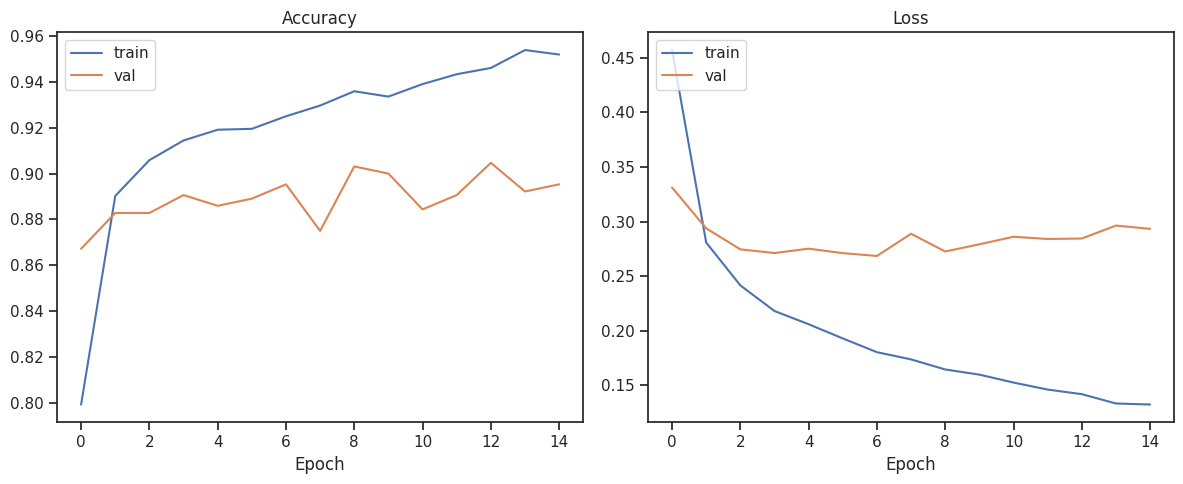

In [32]:
model_gpt = Sequential([
    Dense(64, activation='relu'),
    Dense(1,  activation='sigmoid')
])

model_gpt.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model_gpt.fit(
    X_train_embeddings_gpt,
    y_train_numerical,
    epochs=15,
    validation_split=0.2)

plot_training_history(history)

## Ejercicio (no evaluable)
Compara los modelos creados usando los datos de la partición de test.